Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg

jlPkg.activate(".")
#jlPkg.instantiate() #run the first time using this repo
jl.include("models/model_host_cutoff.jl")


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `c:\Users\micha\GeneCircuitsRL`


  0.773956 seconds (2.26 M allocations: 126.100 MiB, 99.58% compilation time)


denormalize_action (generic function with 1 method)

  3.682722 seconds (51.70 M allocations: 5.995 GiB, 12.82% gc time, 1.15% compilation time)


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

class Regressor(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

model_load = Regressor(input_dim=4, hidden_dim=32)
model_load.load_state_dict(torch.load("regressor_model.pth"))

model_load.eval()

Regressor(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [3]:
import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding
from stable_baselines3 import PPO
log_dir = "logs/rl_host_cutoff"

class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        self.obs_dim = 2           # observation: expression and growth
        self.action_dim = 1        
        self.uncertain_dim = 3     # hidden state (uncertain parameters)
        self.n_steps = max_episode_steps

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32,
        )

        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)
        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)

    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]

    def reset(self, seed=None, options=None):
        if options is not None and "uncertain" in options:
            self.uncertain = np.array(options["uncertain"], dtype=np.float32)
        else:
            self.uncertain = np.random.rand(self.uncertain_dim).astype(np.float32)

        if seed is not None:
            self.seed(seed)

        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    def step(self, action):
        action = np.clip(action, -1, 1).astype(np.float32)
        action_scalar = float(action[0])

        obs_vector = np.array(jl.experession_and_growth(self.uncertain,np.exp(action_scalar*10))) + np.random.rand(2)*(0.1,0.05)

        
        xx = np.hstack([self.uncertain, [0.8]])
        x_t = torch.tensor([xx], dtype=torch.float32)
        with torch.no_grad():
            y_pred_log = model_load(x_t).numpy().squeeze()
            y_pred = y_pred_log/10

        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action # Effective observation = history

        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), -np.abs(y_pred-action.item()), terminated, truncated, info


Training

In [ ]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
# Running this cell will overide any existing monitors
log_dir = "logs/rl_host_cutoff/"
os.makedirs(log_dir, exist_ok=True)


SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})") 
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

model = PPO(
    "MlpPolicy", 
    env,
    verbose=1,
    tensorboard_log=log_dir, 
    seed=SEED,
    learning_rate=3e-4,
    clip_range=0.01,

)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [217]:
# Train the model
model.learn(total_timesteps=2_000_000)
# runtime 51min 44s

# Save the model
model.save(os.path.join(log_dir, "ppo_model"))

Logging to logs/rl_host_cutoff/PPO_20
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | -1.92    |
| time/              |          |
|    fps             | 153      |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 5            |
|    ep_rew_mean          | -1.92        |
| time/                   |              |
|    fps                  | 150          |
|    iterations           | 2            |
|    time_elapsed         | 27           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 7.511664e-05 |
|    clip_fraction        | 0.173        |
|    clip_range           | 0.01         |
|    entropy_loss         | -1.41        |
|    explained_varia

Evaluation

In [4]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

model = PPO.load(model_path)


df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

C:\Users\micha\AppData\Local\Temp\ipykernel_47772\1264227209.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  x_t = torch.tensor([xx], dtype=torch.float32)


[0.38780555] 4.24882
Reward at step 0: -0.061118751764297485
[0.33728826] 3.3717196
Reward at step 1: -0.010601460933685303
[0.31147826] 2.9707246
Reward at step 2: -0.015208542346954346
[0.31495053] 3.0295823
Reward at step 3: -0.011736273765563965
[0.3154333] 3.0582955
Reward at step 4: -0.011253505945205688


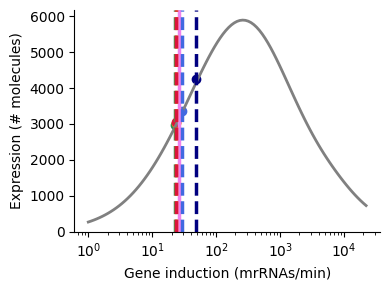

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
obs, info = env.reset(1)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.denormalize_expression(jl.experession_and_growth(env.uncertain, np.exp(i/10))[0])

plt.figure(figsize=(4, 3))
plt.plot(np.exp(np.linspace(0, 1, 100)*10), vals, label='Expression', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=jl.denormalize_action(y_pred), color="violet", linewidth=2.5, label=f'Optimal')

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=jl.denormalize_action(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step])
    plt.scatter(jl.denormalize_action(action[0]),jl.denormalize_expression(obs[0,3*step]),color=colors[step])
    print(f"Reward at step {step}: {reward}")

plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_1.pdf", format="pdf")
plt.show()


[0.38780555] 0.749118
Reward at step 0: -0.061118751764297485
[0.33728826] 0.7994479
Reward at step 1: -0.010601460933685303
[0.31147826] 0.82050997
Reward at step 2: -0.015208542346954346
[0.31495053] 0.82911766
Reward at step 3: -0.011736273765563965
[0.3154333] 0.83821213
Reward at step 4: -0.011253505945205688


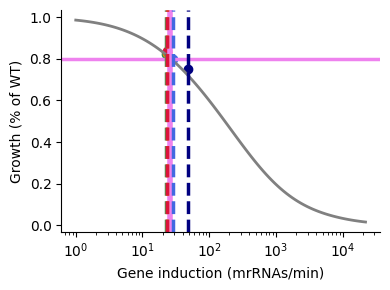

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
obs, info = env.reset(1)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]

plt.figure(figsize=(4, 3))
plt.plot(np.exp(np.linspace(0, 1, 100)*10), vals, label='Growth', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=jl.denormalize_action(y_pred), color="violet", linewidth=4, label=f'Optimal')
plt.axhline(y=0.8, color="violet", linewidth=2.5, label=f'Desired minimal growth')

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=jl.denormalize_action(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step+1])
    plt.scatter(jl.denormalize_action(action[0]),obs[0,3*step+1],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Growth (% of WT)')
# plt.title('Progression of Actions on the Reward Landscape')
# plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_1_growth.pdf", format="pdf")
plt.show()


[0.38780555] 3.4586332
Reward at step 0: -0.056663960218429565
[0.43273255] 4.3679786
Reward at step 1: -0.011736959218978882
[0.4215416] 4.105439
Reward at step 2: -0.022927910089492798
[0.42837942] 4.2763205
Reward at step 3: -0.016090095043182373
[0.4278197] 4.1922126
Reward at step 4: -0.01664981245994568


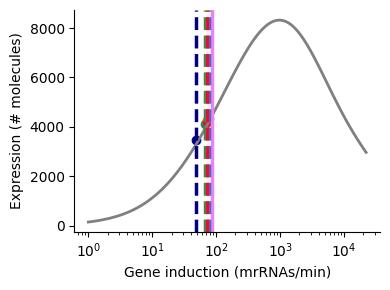

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(6)
obs, info = env.reset(4)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.denormalize_expression(jl.experession_and_growth(env.uncertain, np.exp(i/10))[0])

plt.figure(figsize=(4, 3))
plt.plot(np.exp(np.linspace(0, 1, 100)*10), vals, label='Expression', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=jl.denormalize_action(y_pred), color="violet", linewidth=2.5, label=f'Optimal')

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=jl.denormalize_action(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step])
    plt.scatter(jl.denormalize_action(action[0]),jl.denormalize_expression(obs[0,3*step]),color=colors[step])
    print(f"Reward at step {step}: {reward}")

plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_2.pdf", format="pdf")
plt.show()


[0.38780555] 0.8887586
Reward at step 0: -0.056663960218429565
[0.43273255] 0.8522067
Reward at step 1: -0.011736959218978882
[0.4215416] 0.83930594
Reward at step 2: -0.022927910089492798
[0.42837942] 0.82152665
Reward at step 3: -0.016090095043182373
[0.4278197] 0.84355915
Reward at step 4: -0.01664981245994568


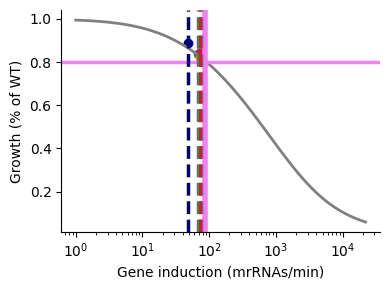

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(6)
obs, info = env.reset(4)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]


plt.figure(figsize=(4, 3))
plt.plot(np.exp(np.linspace(0, 1, 100)*10), vals, label='Growth', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=jl.denormalize_action(y_pred), color="violet", linewidth=4, label=f'Optimal')
plt.axhline(y=0.8, color="violet", linewidth=2.5, label=f'Desired minimal growth')

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=jl.denormalize_action(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step+1])
    plt.scatter(jl.denormalize_action(action[0]),obs[0,3*step+1],color=colors[step])
    print(f"Reward at step {step}: {reward}")

plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Growth (% of WT)')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_2_growth.pdf", format="pdf")
plt.show()


[0.38780555] 0.4303301
Reward at step 0: -0.3167429268360138
[0.6206243] 2.520826
Reward at step 1: -0.08392417430877686
[0.68819255] 3.765359
Reward at step 2: -0.016355931758880615
[0.6774658] 3.5474272
Reward at step 3: -0.02708268165588379
[0.6991185] 3.9018576
Reward at step 4: -0.005429983139038086


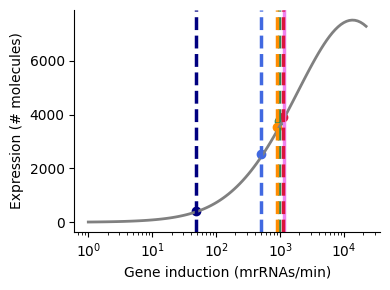

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)
obs, info = env.reset(17)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.denormalize_expression(jl.experession_and_growth(env.uncertain, np.exp(i/10))[0])

plt.figure(figsize=(4, 3))
plt.plot(np.exp(np.linspace(0, 1, 100)*10), vals, label='Expression', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=jl.denormalize_action(y_pred), color="violet", linewidth=2.5, label=f'Optimal')

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=jl.denormalize_action(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step])
    plt.scatter(jl.denormalize_action(action[0]),jl.denormalize_expression(obs[0,3*step]),color=colors[step])
    print(f"Reward at step {step}: {reward}")

plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Expression (# molecules)')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_3.pdf", format="pdf")
plt.show()


[0.38780555] 1.0098593
Reward at step 0: -0.3167429268360138
[0.6206243] 0.8903926
Reward at step 1: -0.08392417430877686
[0.68819255] 0.8568388
Reward at step 2: -0.016355931758880615
[0.6774658] 0.86416364
Reward at step 3: -0.02708268165588379
[0.6991185] 0.8297934
Reward at step 4: -0.005429983139038086


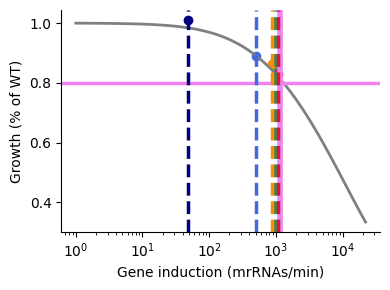

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)
obs, info = env.reset(17)

xx = np.hstack([env.uncertain, [0.8]])
x_t = torch.tensor([xx], dtype=torch.float32)
with torch.no_grad():
    y_pred_log = model_load(x_t).numpy().squeeze()
    y_pred = y_pred_log/10

vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.experession_and_growth(env.uncertain, np.exp(i/10))[1]

plt.figure(figsize=(4, 3))
plt.plot(np.exp(np.linspace(0, 1, 100)*10), vals, label='Growth', color='gray', linewidth=2)

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

plt.axvline(x=jl.denormalize_action(y_pred), color="violet", linewidth=4, label=f'Optimal')
plt.axhline(y=0.8, color="violet", linewidth=2.5, label=f'Desired minimal growth')

for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=jl.denormalize_action(action[0]), color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,3*step+1])
    plt.scatter(jl.denormalize_action(action[0]),obs[0,3*step+1],color=colors[step])
    print(f"Reward at step {step}: {reward}")

plt.xscale('log')
plt.xlabel('Gene induction (mrRNAs/min)')
plt.ylabel('Growth (% of WT)')
sns.despine()
plt.tight_layout()
plt.savefig("action_progression_3_growth.pdf", format="pdf")
plt.show()


In [293]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

first_growths = np.zeros(1000)
second_growths = np.zeros(1000)
third_growths = np.zeros(1000)
forth_growths = np.zeros(1000)
fifth_growths = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = reward
    first_growths[i] = obs[0,1]
    second_growths[i] = obs[0,4]
    third_growths[i] = obs[0,7]
    forth_growths[i] = obs[0,10]
    fifth_growths[i] = obs[0,13]



Text(0, 0.5, 'Reward')

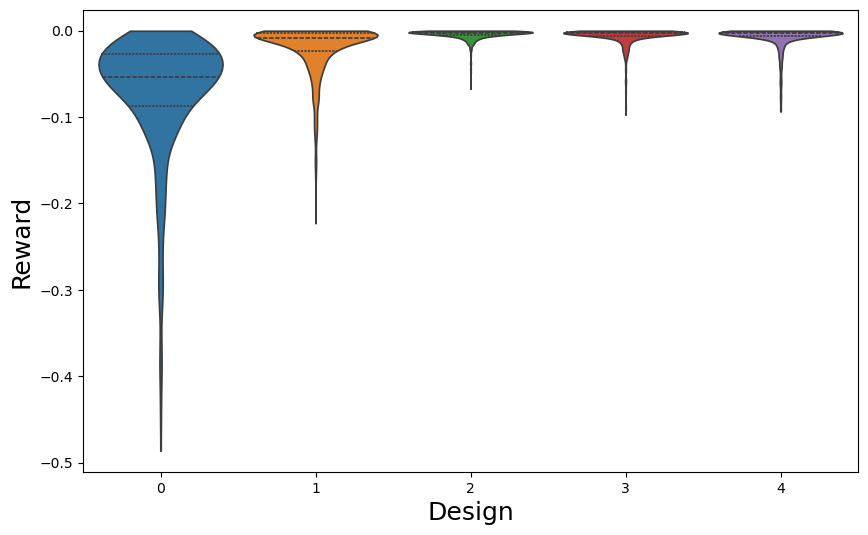

In [62]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile", cut = 0)
plt.xlabel("Step", fontsize=18)
plt.ylabel("Reward", fontsize=18)


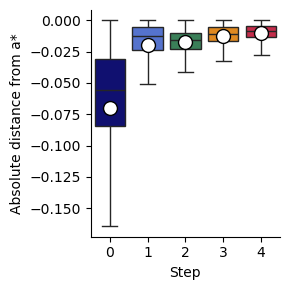

In [374]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']

plt.figure(figsize=(3, 3))
sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    showfliers=False,   # hides outliers
    showmeans=True,     # shows mean
    palette=colors,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":10}
)
plt.xlabel("Step")
plt.ylabel("Absolute distance from a*")
plt.tight_layout()
sns.despine()
plt.savefig("reward_boxplot.pdf", format="pdf")
plt.show()


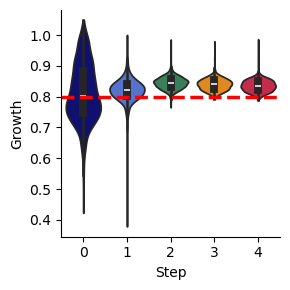

In [376]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
sns.violinplot(
    data=[first_growths, second_growths, third_growths, forth_growths, fifth_growths], palette=colors ,cut=0
)
plt.axhline(y=0.8, color="red", linestyle='--', linewidth=2.5, label=f'Desired minimal growth')
plt.xlabel("Step")
plt.ylabel("Growth")
plt.tight_layout()
sns.despine()
plt.savefig("growth_violinplot.pdf", format="pdf")
plt.show()
